# Predictive spiking controller with integrated voltage dynamics 

The complete predictive spiking controller used in the thesis. Unlike the
instantaneous version, the neuron voltage is now integrated over time as a
leaky dynamical variable.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm

In [12]:
A = np.array([
    [0.0, 1],            # position rate = 1 * velocity
    [-0.1, -0.1]         # velocity rate = stiffness + damping
])

B = np.array([           # spike-to-force map  
    [0.0, 0.0],
    [2.0, -2.0]          # N1 spikes velocity with +2 and N2 spikes velocity with -2
])


C  = np.diag([20.0, 1.0])      # cost weights: position penalised 20x more than velocity

T = 100                  # total simulated time (s)
dt = 0.01                # output sampling step
t_eval = np.arange(0, T, dt)
f  = 0.1                 # predictive horizon (s)
mu = 0.1                 # spike cost
z_schedule = [(5.0, 5.0), (15.0, 10.0), (30.0, 15.0)]     # (time, target) steps
x0 = [0.0, 0.0]

Af = expm(A * f)
G  = B.T @ Af.T @ C

thresholds = np.zeros(B.shape[1])
# Spike threshold per neuron
for i in range(B.shape[1]):
    thresholds[i] = 0.5 * B[:, i] @ Af.T @ C @ Af @ B[:, i] + mu


F_mat = G @ Af @ (A + np.eye(A.shape[0]))   # how the (predicted) state pulls the drive down
Omega = G @ Af @ B                          # self-reset applied when a neuron spikes


sigma_m = 0.5    # measurement noise
sigma_v = 0.5    # voltage noise
sigma_p = 0.5    # process noise

# low-pass filter the step schedule into a smooth reference z(t)
def get_target(t, z_prev, dt):
    z_base = 0.0
    for t_point, val in z_schedule:
        if t >= t_point:
            z_base = val
    return z_prev + dt * 0.5 * (z_base - z_prev)

In [13]:
N  = B.shape[1]
nT = len(t_eval)

x         = np.zeros((nT, 2))
z         = np.zeros(nT)
V_arr     = np.zeros((nT, N))
s_history = np.zeros((nT, N))

x[0]   = x0
V_arr[0] = G @ (np.array([z[0], 0.0]) - Af @ x[0])

for i in range(nT - 1):
    z[i+1]     = get_target(t_eval[i], z[i], dt)
    target_vec = np.array([z[i], 0.0])                              # desired [position, velocity]

    z_base_i = 0.0
    for t_point, val in z_schedule:
        if t_eval[i] >= t_point:
            z_base_i = val
    target_dot_vec = np.array([0.5 * (z_base_i - z[i]), 0.0])       # ż: rate of change of the reference

    x_measured = x[i] + sigma_m * np.random.standard_normal(N)      # noisy state estimate

    V_current  = V_arr[i]
    difference = V_current - thresholds
    s = np.zeros(N)
    if difference.max() > 0:
        s[np.argmax(difference)] = 1.0                              # winner-take-all: one spike for the best neuron
    s_history[i] = s

    noise_p    = sigma_p * np.random.standard_normal(N) * np.sqrt(dt)
    x[i+1]    = x[i] + dt * (A @ x[i]) + B @ s + noise_p           # noisy plant update

    # leaky-integrator voltage dynamics with spike-driven reset (−Ω·s) and voltage noise
    V_dot      = (-V_current + G @ (target_dot_vec + target_vec) - F_mat @ x_measured)
    V_arr[i+1] = (V_current + dt * V_dot - Omega @ s + sigma_v * np.sqrt(dt) * np.random.standard_normal(N))


Total spikes:           645
  Neuron breakdown:     [355 290]
Cumulative error:       50.478
Efficiency ratio:       12.7778 spikes / error-unit


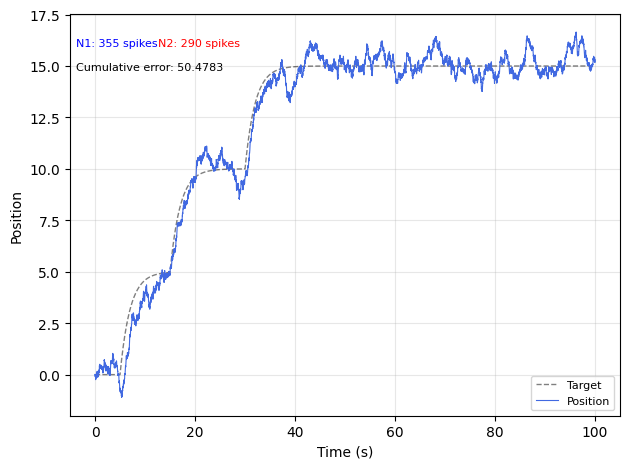

In [14]:
position_error = np.abs(x[:, 0] - z)
cumulative_error = np.cumsum(position_error) * dt

spike_counts = s_history.sum(axis=0).astype(int)
total_spikes = spike_counts.sum()

final_cumulative_error = cumulative_error[-1]
efficiency_ratio = total_spikes / final_cumulative_error

print(f"Total spikes:           {total_spikes}")
print(f"  Neuron breakdown:     {spike_counts}")
print(f"Cumulative error:       {final_cumulative_error:.3f}")
print(f"Efficiency ratio:       {efficiency_ratio:.4f} spikes / error-unit")

plt.plot(t_eval, z, 'k--', alpha=0.5, linewidth=1, label='Target')
plt.plot(t_eval, x[:, 0], color='royalblue', linewidth=0.8, label='Position')

plt.ylabel('Position')
plt.xlabel('Time (s)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

ax = plt.gca()

for j, c in enumerate(spike_counts):
    ax.text(
        0.01 + j * 0.15, 0.92,
        f'N{j+1}: {c} spikes',
        transform=ax.transAxes,
        fontsize=8,
        color=['blue', 'red'][j]
    )

ax.text(
    0.01, 0.86,
    f'Cumulative error: {final_cumulative_error:.4f}',
    transform=ax.transAxes,
    fontsize=8,
    color='black'
)

plt.tight_layout()
plt.show()


Total spikes:           645
  Neuron breakdown:     [355 290]
Cumulative error:       50.478
Efficiency ratio:       12.7778  spikes / error-unit


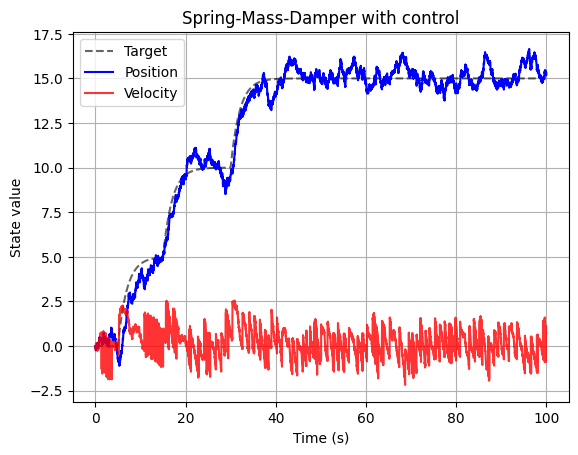

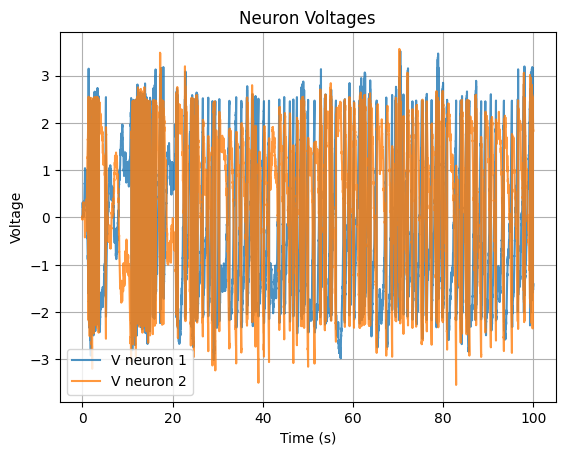

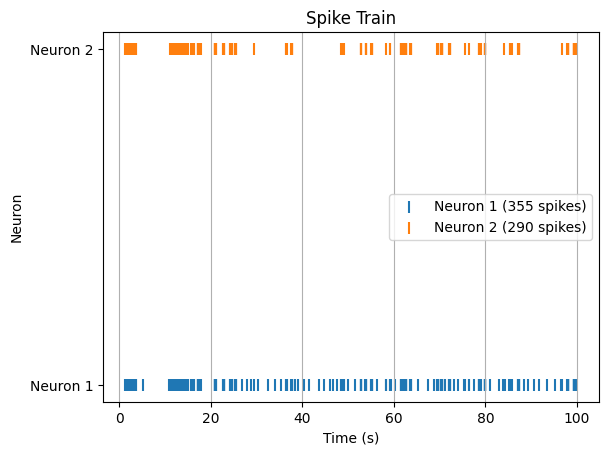

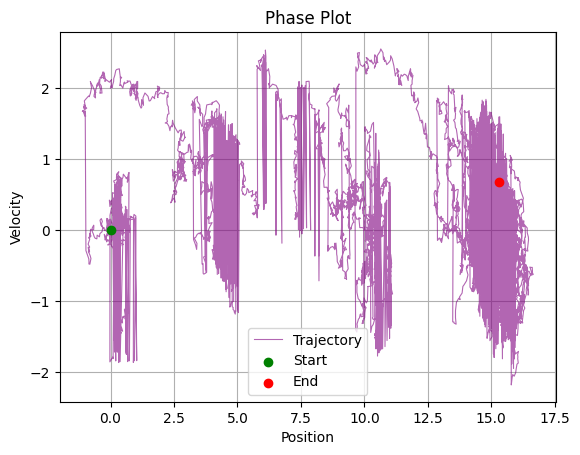

In [15]:
position_error = np.abs(x[:, 0] - z)
cumulative_error = np.cumsum(position_error) * dt

spike_counts = s_history.sum(axis=0).astype(int)
total_spikes  = spike_counts.sum()

final_cumulative_error = cumulative_error[-1]
efficiency_ratio = total_spikes / final_cumulative_error

print(f"Total spikes:           {total_spikes}")
print(f"  Neuron breakdown:     {spike_counts}")
print(f"Cumulative error:       {final_cumulative_error:.3f}")
print(f"Efficiency ratio:       {efficiency_ratio:.4f}  spikes / error-unit")

plt.plot(t_eval, z, 'k--', alpha=0.6, label="Target")
plt.plot(t_eval, x[:, 0], color='blue',  label="Position")
plt.plot(t_eval, x[:, 1], color='red', alpha=0.8, label="Velocity")
plt.xlabel("Time (s)")
plt.ylabel("State value")
plt.title("Spring-Mass-Damper with control")
plt.legend()
plt.grid()
plt.show()

plt.figure()
for j in range(N):
    plt.plot(t_eval, V_arr[:, j], alpha=0.8, label=f"V neuron {j+1}")
plt.xlabel("Time (s)")
plt.ylabel("Voltage")
plt.title("Neuron Voltages")
plt.legend()
plt.grid()
plt.show

plt.figure()
for j in range(N):
    spike_times = t_eval[s_history[:, j] == 1.0]
    plt.scatter(
        spike_times,
        np.full(len(spike_times), j + 1),
        marker='|',
        s=80,
        label=f"Neuron {j+1} ({spike_counts[j]} spikes)"
    )
plt.xlabel("Time (s)")
plt.ylabel("Neuron")
plt.title("Spike Train")
plt.yticks(range(1, N + 1), [f"Neuron {j+1}" for j in range(N)])
plt.legend()
plt.grid(axis='x')
plt.show()

plt.figure()
plt.plot(x[:, 0], x[:, 1], color='purple', alpha=0.6, linewidth=0.8, label="Trajectory")
plt.scatter(x[0, 0], x[0, 1], color='green', zorder=5, label="Start")
plt.scatter(x[-1, 0], x[-1, 1], color='red', zorder=5, label="End")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Phase Plot")
plt.legend()
plt.grid()
plt.show()

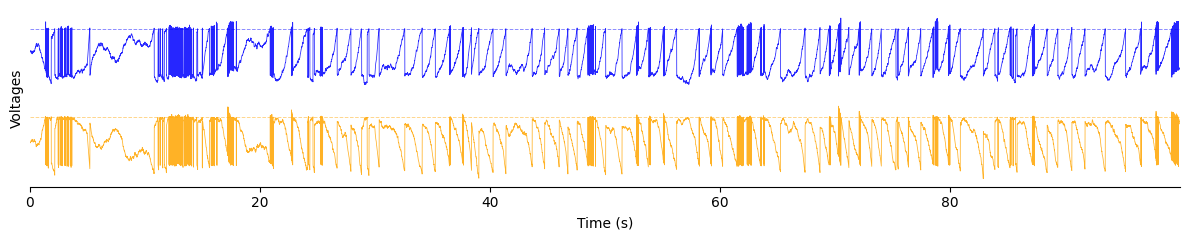

In [16]:
colors = ['blue', 'orange']

gap    = 5
fig, ax = plt.subplots(figsize=(12, 2.5))

for j in range(N):
    v = V_arr[:, j]
    v_norm = (v - np.mean(v)) / (np.std(v) + 1e-9)  
    offset = (N - 1 - j) * gap 
    ax.plot(t_eval, v_norm + offset,
            color=colors[j % len(colors)], linewidth=0.55, alpha=0.85)
    thr_norm = (thresholds[j] - np.mean(v)) / (np.std(v) + 1e-9)
    ax.axhline(thr_norm + offset, color=colors[j % len(colors)],
               linewidth=0.7, linestyle='--', alpha=0.45)

ax.set_yticks([])
ax.set_ylabel('Voltages', fontsize=10)
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_xlim(t_eval[0], t_eval[-1])
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()

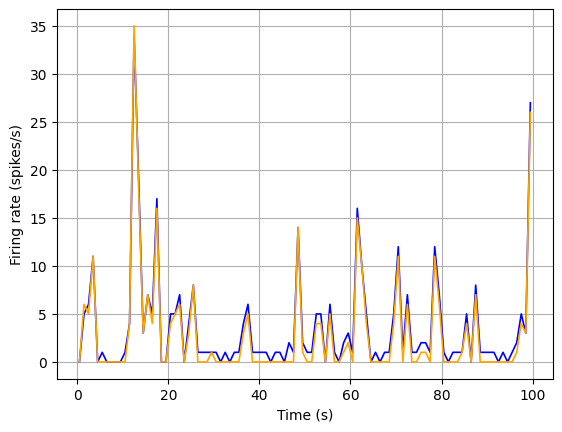

In [17]:
plt.figure()

bins = np.arange(0, T + 1, 1)
bin_centres = bins[:-1] + 1 / 2
for j in range(N):
    spike_times = t_eval[s_history[:, j] == 1.0]
    counts, _ = np.histogram(spike_times, bins=bins)
    plt.plot(bin_centres, counts,
                 color=colors[j], linewidth=1.2, label=f"Neuron {j+1}")
plt.xlabel("Time (s)")
plt.ylabel("Firing rate (spikes/s)")
plt.grid()
plt.show()

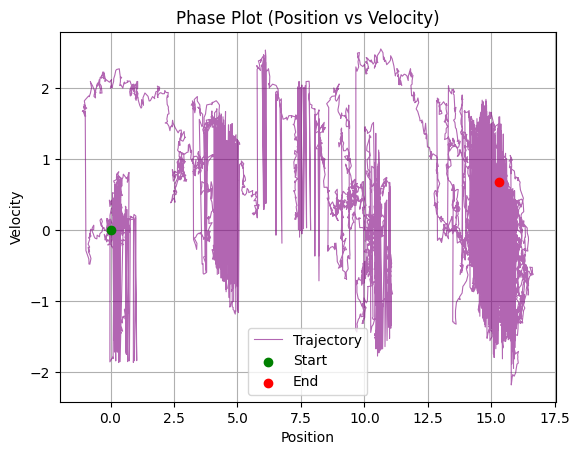

In [18]:
plt.figure()
plt.plot(x[:, 0], x[:, 1], color='purple', alpha=0.6, linewidth=0.8, label="Trajectory")
plt.scatter(x[0, 0], x[0, 1], color='green', zorder=5, label="Start")
plt.scatter(x[-1, 0], x[-1, 1], color='red',   zorder=5, label="End")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Phase Plot (Position vs Velocity)")
plt.legend()
plt.grid()
plt.show()

In [19]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "ipywidgets"])

0

In [20]:
import ipywidgets as widgets
from IPython.display import display

def run_sim(mu_val, sigma_m_val, sigma_v_val, sigma_p_val):
    thr = np.zeros(B.shape[1])
    for i in range(B.shape[1]):
        thr[i] = 0.5 * B[:, i] @ Af.T @ C @ Af @ B[:, i] + mu_val

    nT = len(t_eval)
    x_s = np.zeros((nT, 2))
    z_s = np.zeros(nT)
    V_s = np.zeros((nT, N))
    s_s = np.zeros((nT, N))

    x_s[0] = x0
    V_s[0] = G @ (np.array([z_s[0], 0.0]) - Af @ x_s[0])

    for i in range(nT - 1):
        z_s[i+1] = get_target(t_eval[i], z_s[i], dt)
        target_vec = np.array([z_s[i], 0.0])
        z_base_i = 0.0
        for t_point, val in z_schedule:
            if t_eval[i] >= t_point:
                z_base_i = val
        target_dot_vec = np.array([0.5 * (z_base_i - z_s[i]), 0.0])

        x_meas = x_s[i] + sigma_m_val * np.random.standard_normal(N)
        V_cur  = V_s[i]
        diff   = V_cur - thr
        s = np.zeros(N)
        if diff.max() > 0:
            s[np.argmax(diff)] = 1.0
        s_s[i] = s

        x_s[i+1] = x_s[i] + dt * (A @ x_s[i]) + B @ s + sigma_p_val * np.random.standard_normal(N) * np.sqrt(dt)
        V_dot    = -V_cur + G @ (target_dot_vec + target_vec) - F_mat @ x_meas
        V_s[i+1] = V_cur + dt * V_dot - Omega @ s + sigma_v_val * np.sqrt(dt) * np.random.standard_normal(N)

    return x_s, z_s, V_s, s_s, thr


slider_kw = dict(style={'description_width': '160px'}, layout=widgets.Layout(width='520px'))
sl_mu  = widgets.FloatSlider(value=0.1,  min=0.01, max=1.0,  step=0.01, description='μ ', **slider_kw)
sl_sm  = widgets.FloatSlider(value=0.0,  min=0.0,  max=2.0,  step=0.05, description='σ_m ', **slider_kw)
sl_sv  = widgets.FloatSlider(value=0.0,  min=0.0,  max=2.0,  step=0.05, description='σ_v ', **slider_kw)
sl_sp  = widgets.FloatSlider(value=0.0,  min=0.0,  max=2.0,  step=0.05, description='σ_p ', **slider_kw)

out = widgets.Output()
_clr = ['steelblue', 'darkorange']

def update(_=None):
    x_s, z_s, V_s, s_s, thr = run_sim(sl_mu.value, sl_sm.value, sl_sv.value, sl_sp.value)
    error = x_s[:, 0] - z_s
    rmse  = np.sqrt(np.mean(error**2))

    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

        ax = axes[0, 0]
        ax.plot(t_eval, z_s,       'k--', alpha=0.55, label='Target')
        ax.plot(t_eval, x_s[:, 0], color=_clr[0],              label='Position')
        ax.plot(t_eval, x_s[:, 1], color='red',   alpha=0.75,  label='Velocity')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('State value')
        ax.set_title('Position & Velocity Tracking')
        ax.legend(); ax.grid()

        ax = axes[0, 1]
        ax.plot(t_eval, error, color='purple', linewidth=0.9, label='Error (pos − target)')
        ax.axhline(0, color='k', linewidth=0.7, linestyle='--')
        ax.fill_between(t_eval, error, alpha=0.15, color='purple')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Error')
        ax.set_title(f'Tracking Error   (RMSE = {rmse:.4f})')
        ax.legend(); ax.grid()

        ax = axes[1, 0]
        for j in range(N):
            ax.plot(t_eval, V_s[:, j], color=_clr[j], linewidth=0.7, alpha=0.85, label=f'V neuron {j+1}')
            ax.axhline(thr[j], color=_clr[j], linewidth=1.0, linestyle='--', alpha=0.5, label=f'Threshold {j+1}')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Voltage')
        ax.set_title('Neuron Voltages & Thresholds')
        ax.legend(fontsize=8); ax.grid()

        ax = axes[1, 1]
        bins = np.arange(0, T + 1, 1)
        bin_c = bins[:-1] + 0.5
        for j in range(N):
            counts, _ = np.histogram(t_eval[s_s[:, j] == 1.0], bins=bins)
            ax.plot(bin_c, counts, color=_clr[j], linewidth=1.2, label=f'Neuron {j+1}')
            total = int(s_s[:, j].sum())
            ax.text(0.98, 0.92 - j * 0.12, f'N{j+1} total spikes: {total}',
                    transform=ax.transAxes, ha='right', fontsize=8, color=_clr[j])
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Firing rate (spikes/s)')
        ax.set_title('Firing Rate per Second')
        ax.legend(); ax.grid()

        fig.suptitle(
            f'μ = {sl_mu.value:.2f}   |   σ_m = {sl_sm.value:.2f}   |   '
            f'σ_v = {sl_sv.value:.2f}   |   σ_p = {sl_sp.value:.2f}',
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

for sl in [sl_mu, sl_sm, sl_sv, sl_sp]:
    sl.observe(update, names='value')

update()

display(widgets.VBox([
    widgets.HTML('<h3 style="margin-bottom:6px">Noise &amp; Parameter Impact Explorer</h3>'),
    sl_mu, sl_sm, sl_sv, sl_sp,
    out
]))